# Mapping the 2025 Eaton and Palisades Wildfires in Los Angeles County
Description: "An analysis of the 2025 Eaton and Palisades wildfires using Landsat satellite imagery and Environmental Justice Index data, visualizing fire perimeters, vegetation impacts, and social vulnerability in affected communities"
- Author: `Marie Tolteca`
- Affiliation: Master of Environmental Data Science Program at The Bren School (UCSB)
- Date: 12/12/2025
- Github: https://github.com/marietolteca00/eds220-hwk4.git

Link to GitHub -> [GitHub](https://github.com/marietolteca00/la_wildfire_and_social_impacts.git)

![Eaton and Palisades Wildfire. NPR. Satellite image ©2025 Maxar Technologies (January 9, 2025)](satellite_image.jpeg)

### Background
The Eaton and Palisades fires were two recent major wildfires that started from strong Santa Ana winds, dry vegetation from previous wet winters, and potential issues with electrical transmission lines. Both wildfires started simultaneously in Los Angeles County on January 07, 2025. These wildfires burned around 60 square miles and destroying thousands of structures and vegetation [(Fritz and Park)](https://www.cnn.com/2025/01/14/climate/los-angeles-fires-worse-global-warming/index.html). A total of 37,000 acres burned across the Eaton and Palisades wildfires [(Hoffman, et. al.,2025)](https://abcnews.go.com/US/la-wildfires-aftermath-insurance-housing-rebuild-update/story?id=119209482).

### Purpose
A NetCDF (.nc) file containing Landsat raster data for Los Angeles County will be used, covering the areas affected by two wildfires in 2025. The file includes a simplified collection of bands: red, green, blue, near-infrared, and shortwave infrared, from Landsat Collection 2 Level-2 atmospherically corrected surface reflectance data, obtained by the Landsat 8 satellite. The Eaton and Palisades fire perimeter shapefiles will be projected onto the Landsat imagery, which will be visualized using false-color composites to highlight burned and vegetated areas. Additionally, potential social factors influencing wildfire impacts are investigated using the California Environmental Justice Index (EJI) dataset.

# About Data
Microsoft Planetary Computer, https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2, is used in this notebook that outlines the fire perimeters for the Palisades and Eaton Fire. This was our data landsat data for the fire perimeters. `landsat8-2025-02-23-palisades-eaton.nc`

From the County of Los Angeles GIS, was retrieved for both fire perimeters of `Palisades` and `Eaton` fire as a shapefile (shp) each were added to a folder. 

- `eji`: Is a geodatabase folder, that has rankings of geographic levels that represent comparison to all other census tracts.
- `eaton_boundary`:` Layer contains a dissolved fire perimeter for the eaton fire. (01/21/2025)
- `palisades_boundary`: Layer contains a dissolved fire perimeter for the palisades fire. (01/21/2025)
- `landsat`: This `nc` file contains a collection of bands (red, blue, green, near-infrared, and shortwave infrared) from the Landsat Collection 2 Level-2 atmosperically adjusted surface reflectance data, obtained by the Landsat 8 satellite. This data has been clipped to an area of Los Angeles County to include both fire perimeters.

This repository contains code and materials for analyzing Landsat imagery and mapping wildfire perimeters in Los Angeles County. It demonstrates how to:
- Work with NetCDF (.nc) Landsat data
- Create true-color (RGB) and false-color composites
- Overlay geospatial data to visualize fire boundaries
- Develop clear and reproducible geospatial workflows
- Identify a social dimension using EJI to explore potential vulnerability patterns within fire perimeters

The focus is on the Eaton and Palisades Fires, combining satellite imagery with official fire perimeter shapefiles to explore fire-affected areas.

### Highlights:
- Data Wrangling
- Restoring geospatial information
- False color imagery
- EJI Social Variable


### Data Access
- The Landsat .nc file can be downloaded from a shared Google Drive folder provided by the instructor for the course EDS 220 – Working with Environmental Datasets: https://drive.google.com/drive/folders/1USqhiMLyN8GE05B8WJmHabviJGnmAsLP
- Fire perimeter shapefiles for the Palisades and Eaton fires were obtained from the County of Los Angeles GIS:
County. https://egis-lacounty.hub.arcgis.com/maps/ad51845ea5fb4eb483bc2a7c38b2370c/about
- Each shapefile contains a dissolved fire perimeter for its respective fire and has been added to the data folder in this repository.
- Centers for Disease Control and Prevention and Agency for Toxic Substances Disease Registry. [2024] Environmental Justice Index. Accessed [2024, December 2]. https://atsdr.cdc.gov/place-health/php/eji/eji-data-download.html

### Packages Used:
This notebook uses the following Python packages: `contextily`, `os`,  `numpy`, `matplotlib.pyplot`, `matplotlib.patches`, `geopandas`, `rioxarray`, and `xarray`.

### Import Libraries

In [1]:
import contextily as ctx
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import rioxarray
import xarray as xr

### Import Data

In [2]:
# Import Landsat `nc` file with os
landsat = xr.open_dataset(os.path.join('data', 'landsat8-2025-02-23-palisades-eaton.nc'))

# Import fire shapefile data
fp = os.path.join('data','eaton_perimeter','Eaton_Perimeter_20250121.shp')
eaton = gpd.read_file(fp)
fp = os.path.join('data','palisades_perimeter','Palisades_Perimeter_20250121.shp')
palisades = gpd.read_file(fp)

eji = gpd.read_file(os.path.join("data","EJI_2024_California","EJI_2024_California.gdb"))


# Data Exploration
### Fire Perimeters and EJI
Let's go ahead and conduct some exploration analysis in our fire paramteres, Eaton and Palisades fire. The first thing I wanted to check was the Coordinate Reprojection System (CRS), the bounding box's, and plot both shapefiles to see how they looked liked and what will have to be done when cleaning up the dataframes.

The CRS for Palisades is: EPSG:3857
The CRS for Eaton is: EPSG:3857
The EJI CRS and Eaton CRS Do Not Match ! 
Is the CRS geographic for Palisades? False
Is the CRS geographic for Eaton? False
Is the CRS projected for Palisades? True
Is the CRS projected for Eaton? True


Text(0.5, 1.0, 'EJI of California')

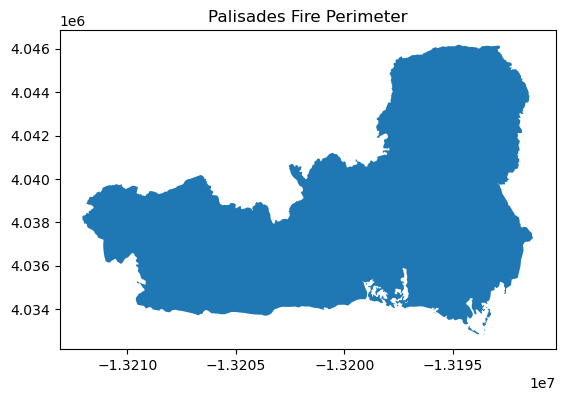

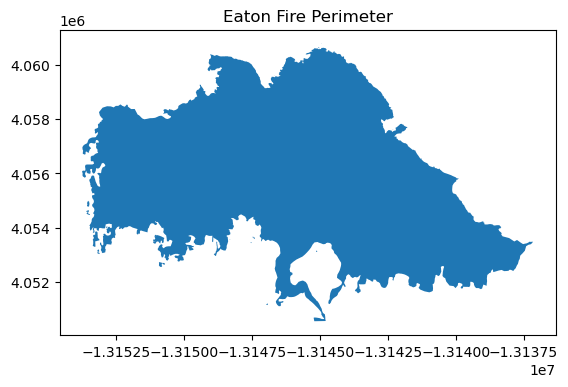

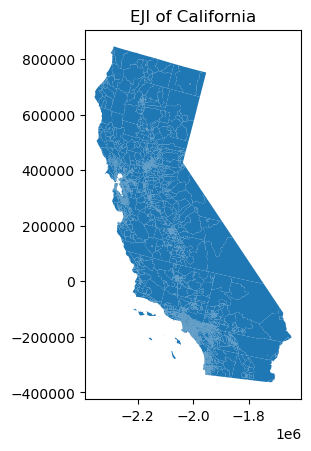

In [3]:
# View landsat
landsat.head()

# Check CRSs
print(f"The CRS for Palisades is: {palisades.crs}")
print(f"The CRS for Eaton is: {eaton.crs}")
if eji.crs != eaton.crs:
  print("The EJI CRS and Eaton CRS Do Not Match ! ")

# Check bounds
#print(f'The bounding box of the Palisades fire is : {palisades.total_bounds}')
#print(f'The bounding box of the Eaton fire is: {eaton.total_bounds}')

# Check if projected or geographic for fire perimeters
print(f"{'Is the CRS geographic for Palisades?' : <25} {palisades.crs.is_geographic}")
print(f"{'Is the CRS geographic for Eaton?' : <25} {eaton.crs.is_geographic}")

print(f"{'Is the CRS projected for Palisades?' : <25} {palisades.crs.is_projected}")
print(f"{'Is the CRS projected for Eaton?' : <25} {eaton.crs.is_projected}")


# View DF's map
palisades.plot()
plt.title('Palisades Fire Perimeter')

eaton.plot()
plt.title('Eaton Fire Perimeter')

eji.plot()
plt.title('EJI of California')


From the data exploration analysis, all of our files have the CRS projected. The CRS for EJI is different compared to both fire perimeters. We can also visually see our the fire perimeters and EJI of California.


# Data Wrangling 
For both the Eaton and Palisades dataframes, all column names were converted to lowercase to ensure consistency and prevent errors when referencing columns later. The code then checks whether the datasets share the same Coordinate Reference System (CRS) and transforms the EJI layer to match the CRS of the fire perimeter datasets. After aligning the CRS, spatial joins are performed between EJI and each fire perimeter to identify overlapping features. Finally, the EJI layer is clipped to each fire perimeter boundary for specific data in each fire perimeter (Eaton and Palisades).

In [4]:
# Lowercase column headers on both eaton and palisades dataframes
for df in [palisades, eaton]:
    df.columns = df.columns.str.lower()

# Match CRS
eaton.crs == palisades.crs  # False
print(f' The CRS for Eaton is: {eaton.crs} and the crs for palisades is: {palisades.crs}')

# Transform CRS
eji = eji.to_crs(palisades.crs)


# Check CRS match
assert eji.crs == palisades.crs
print("The EJI CRS match with Palisades CRS, after transformation :)")

# Spatial Join    
palisadesjoin = gpd.sjoin(eji,palisades)
eatonjoin = gpd.sjoin(eji, eaton)

# Clipping 
palisades_clip = gpd.clip(eji, palisades)
eaton_clip = gpd.clip(eji, eaton)

 The CRS for Eaton is: EPSG:3857 and the crs for palisades is: EPSG:3857
The EJI CRS match with Palisades CRS, after transformation :)


# Landsat Exploration and Wrangling
The Landsat file is first examined using rioxarray to inspect its Coordinate Reference System (CRS). The CRS is then extracted from the spatial_ref metadata in WKT format and written back to the dataset to ensure it is explicitly defined and properly attached for subsequent geospatial analysis. Before processing, any missing values (NaN) in the Landsat bands will be filled to prevent errors, RGB and false-color composites will be created for visualization, and the Eaton and Palisades fire perimeter shapefiles will be reprojected to match the Landsat CRS. A visualization will be made to view False-Color Imagery.

In [5]:
# Check CRS of Landsat
print(f"CRS:, {landsat.rio.crs}")

# Extract CRS using spatial_ref variable
wkt = landsat.spatial_ref.crs_wkt
print("\nCRS WKT from spatial_ref:")
print(wkt)

# Write the CRS to the dataset - geospatial information and spatial reference
landsat = landsat.rio.write_crs(wkt, inplace=False)

# Verify CRS is now attached
print("\nCRS after writing:", landsat.rio.crs)

CRS:, None

CRS WKT from spatial_ref:
PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]

CRS after writing: EPSG:32611


In the Landsat file we will fill NA Values into collection of bands Red, green, and blue. This allows for `no NaN` error message to be removed. We will also assign it to an array.

In [6]:
#  Substitute any NaN values with 0
landsat_filled = landsat.fillna(0)

# Add fillna() back into rgb
rgb_filled = landsat_filled[["red", "green", "blue"]].to_array()

# Assign numpy array to a variable
false_color = landsat[["swir22", "nir08", "red"]].to_array()

After confirming that the CRS is properly attached, the code fills all NaN values in the dataset with zeros to prevent errors during later processing or visualization. The filled dataset is then used to create RGB and false-color composites by selecting the appropriate spectral bands and converting them into NumPy arrays.
### Transform CRS from Eaton and Palisades fire to match Landsat


In [7]:
# Transform Fire Perimeters to match landsat
eaton = eaton.to_crs(landsat.rio.crs)
palisades = palisades.to_crs(landsat.rio.crs)

# Check transformation
assert landsat.rio.crs == eaton.crs
assert landsat.rio.crs == palisades.crs

Since, Landsat dataset will be used as the base imagery, the Eaton and Palisades fire perimeter datasets must be reprojected to match the CRS of the Landsat file. The code transforms both fire perimeter layers to the Landsat CRS and then prints their CRS values to verify that the transformation was successful.

### False-Color Landsat Imagery
#### Eaton and Palisades Fire Perimeters
False-color imagery assigns non-visible wavelengths (like infrared) to the red, green, and blue color channels to reveal features not apparent in natural color images. This analysis uses a SWIR, NIR, and Red composite where short-wave infrared (SWIR), near-infrared (NIR), and red bands are displayed, making it particularly effective for assessing wildfire damage. In the false-color imagery composite, healthy vegetation appears bright green due to high near-infrared reflectance, while burned areas show as dark brown. The following visualization overlays the Eaton and Palisades fire perimeters on this false-color composite to assess fire extent and severity.

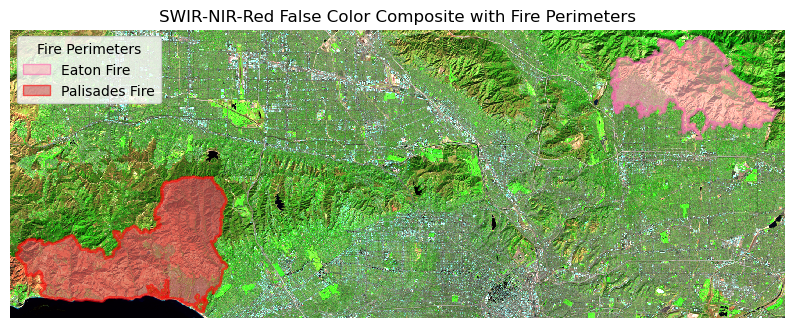

In [8]:
# Set up fig, ax
fig, ax = plt.subplots(figsize=(10,10))

# Plot false-color background first
false_color.plot.imshow(robust=True)

# Overlay fire perimeters
eaton.boundary.plot(ax=ax, color="hotpink", linewidth=2, label="Eaton Fire", facecolor = "lightpink", alpha = 0.6)
palisades.boundary.plot(ax=ax, color="red", linewidth=2, label="Palisades Fire", facecolor = "indianred", alpha = 0.6)

# Legend Patches
pal_legend = mpatches.Patch(facecolor="indianred", edgecolor="red", alpha=0.6, label="Palisades Fire")
eaton_legend = mpatches.Patch(facecolor="lightpink", edgecolor="hotpink", alpha=0.6, label="Eaton Fire")

# Zoom to fire extents - This is for the bound limits
xmin = min(eaton.total_bounds[0], palisades.total_bounds[0]) - 500
xmax = max(eaton.total_bounds[2], palisades.total_bounds[2]) + 500
ymin = min(eaton.total_bounds[1], palisades.total_bounds[1]) - 500
ymax = max(eaton.total_bounds[3], palisades.total_bounds[3]) + 500

# Set limits
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax) 

# Title
ax.set_title("SWIR-NIR-Red False Color Composite with Fire Perimeters")

# Legend
ax.legend(handles=[eaton_legend, pal_legend], 
          loc="upper left",
          title="Fire Perimeters",
          # Background of legend
          frameon=True)
ax.set_axis_off()
plt.show()

#### Interpretation
The false-color composite effectively reveals the wildfire impact across Los Angeles County. Bright green areas indicate healthy vegetation with high near-infrared reflectance, while dark brown areas within the fire perimeters show where vegetation has been destroyed. The Palisades Fire (red boundary) and Eaton Fire (pink boundary) extents are clearly visible, with burned areas appearing as distinctly darker patches compared to surrounding unburned landscape.

# Eaton and Palisades Fire Perimeters (Basemap)
To better understand the spatial extent and location of the Eaton and Palisades fires relative to surrounding communities and infrastructure, we will use `OpenStreeMap` basemap. With the OpenStreetMap, it will overlay the fire perimeters, which provides roads, highways, and city boundaries for geographic context. The Eaton and Palisades clipped version will be used here.

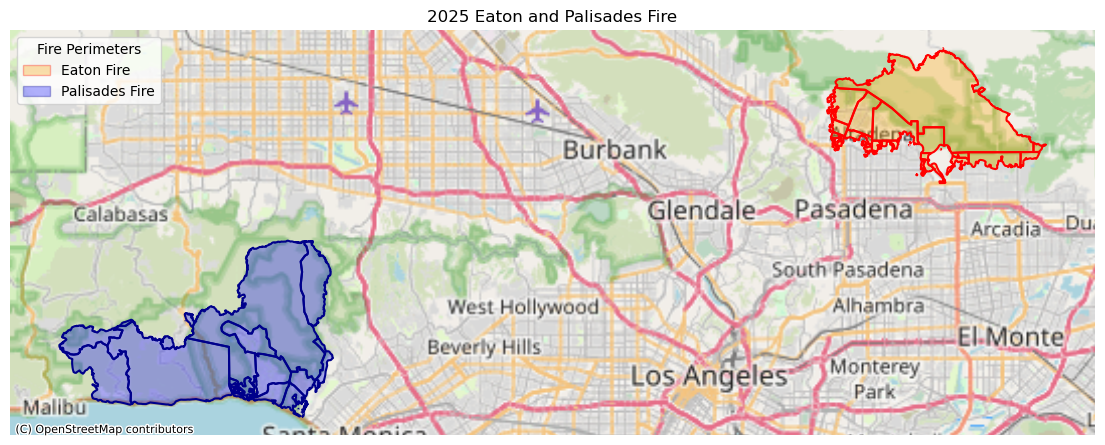

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Fire Perimeter- Eaton
eaton_clip.plot(ax=ax, color='orange', alpha=0.3)  # Inside
eaton_clip.plot(ax=ax, color='none', edgecolor='red', linewidth=1.5)  # Border

# Fire Perimeter- Palisades
palisades_clip.plot(ax=ax, color='blue', alpha=0.3)  # Inside
palisades_clip.plot(ax=ax, color='none', edgecolor='darkblue', linewidth=1.5)  # Border

# Legend Patches
pal_legend = mpatches.Patch(facecolor="blue", edgecolor="darkblue", alpha=0.3, label="Palisades Fire")
eaton_legend = mpatches.Patch(facecolor="orange", edgecolor="red", alpha=0.3, label="Eaton Fire")

# Legend
ax.legend(handles=[eaton_legend, pal_legend], 
          loc="upper left",
          title="Fire Perimeters",
          # Background of legend
          frameon=True)

# Title
ax.set_title("2025 Eaton and Palisades Fire")

# Axes off
ax.axis('off')

# Basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()

#### Interpretation
This map shows the Eaton and Palisades fire perimeters overlaid on an OpenStreetMap basemap, providing crucial geographic context. Compared to the earlier Landsat false-color imagery, this visualization makes it much easier to identify which specific communities, roads, and infrastructure were affected by each fire. The basemap reveals that both fires occurred in densely populated areas of Los Angeles County, with major highways and residential neighborhoods clearly visible within and adjacent to the fire boundaries. The semi-transparent fire perimeters allow viewers to see underlying street networks and topography, helping to understand how terrain and urban development may have influenced fire spread patterns. 

# EJI Spatial Join and Clip
### EJI U.S. Census Tracts with Eaton and Palisades Fire Perimeters
Before performing any spatial analysis, the EJI census tract dataset was reprojected to match the CRS of the Eaton and Palisades fire perimeter datasets to ensure consistent spatial alignment across all layers. Although spatial joins and clipping were performed earlier, reprojection had not been performed, making this step necessary to enable valid spatial overlay operations.
In this section, spatial joins are used to identify U.S. census tracts that intersect with the Eaton and Palisades fire perimeters, helping determine which communities were impacted by each fire. The EJI census tract data are then clipped to the fire perimeter boundaries to extract only the portions of tracts located within the burned areas.

### Reprojection
Reproject EJI to match Palisades and Eaton CRS, before spatial join. These steps are repeated from data wrangling section since now reprojection was made in order to clip the EJI census tracts.

In [10]:
# Reproject EJI to match Palisades CRS
if eji.crs != palisades.crs:
  # Transform if CRS are different
    eji = eji.to_crs(palisades.crs)

if eji.crs != eaton.crs:
    # Transform if CRS are different
    eji = eji.to_crs(eaton.crs)

### Spatial Join
In this section, the information in EJI will be joined with the fire perimeter of Eaton and Palisades, using intersects.
A spatial join identifies ALL census tracts that have ANY overlap with the fire perimeters, even if only partially affected. This allows to view a complete list of potentially impacted communities. A visual plot will be shown to visually see the spatial joins.

In [11]:
# Spatially join EJI and Palisades
eji_palisades = gpd.sjoin(eji,palisades,predicate="intersects")

In [12]:
# Spatially join EJI and Eaton
eji_eaton = gpd.sjoin(eji,eaton,predicate="intersects")

### Visualize Eaton and Palisades (Joined EJI)


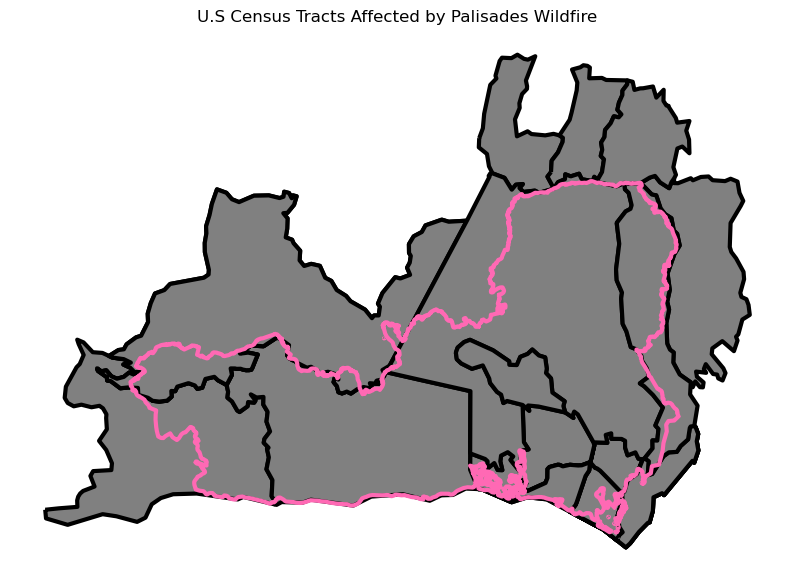

In [13]:
# Define figure and axis dimensions
fig, ax= plt.subplots(figsize = (10,10))

# Joined with EJI
eji_palisades.plot(ax=ax, edgecolor= "black", facecolor= "grey", linewidth = 3)

# Palisades Reprojected
palisades.plot(ax=ax, edgecolor= "hotpink", color= "none", linewidth = 3)

# Set title
ax.set_title("U.S Census Tracts Affected by Palisades Wildfire")

# Turn off axis ticks
ax.set_axis_off()


# Show plot
plt.show()

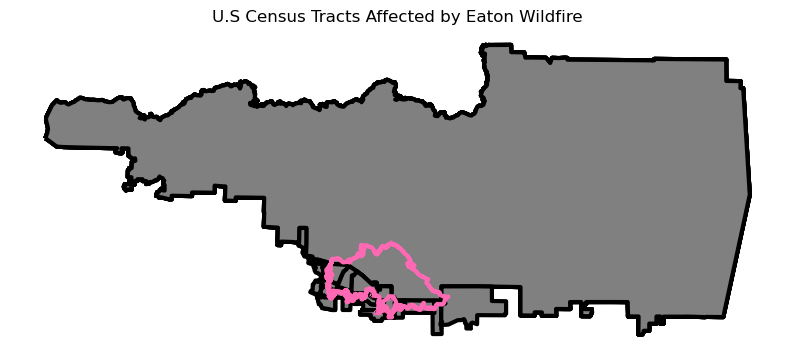

In [14]:
# Define figure and axis dimensions
fig, ax= plt.subplots(figsize = (10,10))

# Joined with EJI
eji_eaton.plot(ax=ax, edgecolor= "black", facecolor= "grey", linewidth = 3)

# Eaton Reprojected
eaton.plot(ax=ax, edgecolor= "hotpink", color= "none", linewidth = 3)

# Set title
ax.set_title("U.S Census Tracts Affected by Eaton Wildfire")

# Turn off axis ticks
ax.set_axis_off()


# Show plot
plt.show()

The spatial join identified all census tracts that intersect the fires, but included areas outside the fire boundaries.

### Clip EJI with Fire Perimeters
As shown in the spatial join visualizations above, the census tracts extend beyond the fire perimeters, meaning we're including areas that were not actually burned. Since we're only interested in analyzing communities directly impacted within the fire boundaries, we'll use clipping (`gpd.clip()`) to extract only the portions of census tracts that fall within the fire perimeters. A visualization will be provided for both Eaton and Palisades fire perimeteres 

In [15]:
# Clip EJI onto Palisades Perimeter
eji_palisades_clip = gpd.clip(eji,palisades)

In [16]:
# Clip EJI onto Palisades Perimeter
eji_eaton_clip = gpd.clip(eji,eaton)

### Visualize Clip of EJI and Fire Perimeters


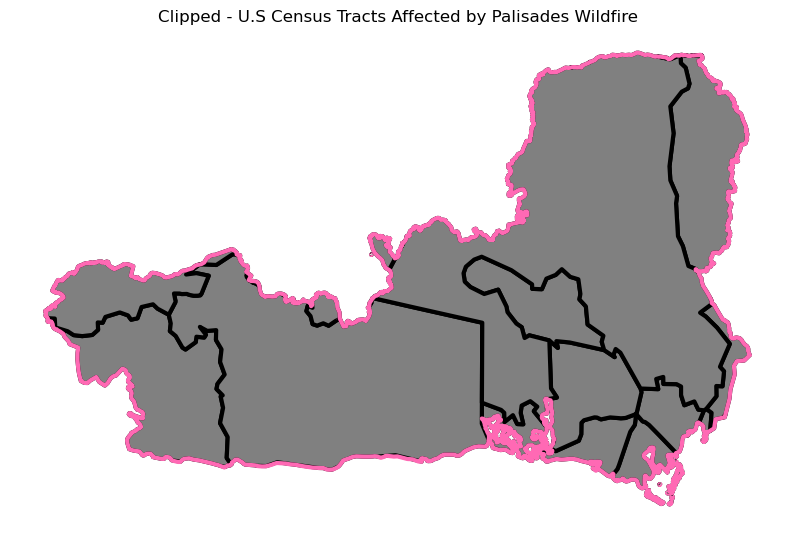

In [17]:
# Define figure and axis dimensions
fig, ax= plt.subplots(figsize = (10,10))

# Joined with EJI
eji_palisades_clip.plot(ax=ax, edgecolor= "black", facecolor= "grey", linewidth = 3)

# Palisades Reprojected
palisades.plot(ax=ax, edgecolor= "hotpink", color= "none", linewidth = 3)

# Set title
ax.set_title("Clipped - U.S Census Tracts Affected by Palisades Wildfire")

# Turn off axis ticks
ax.set_axis_off()


# Show plot
plt.show()

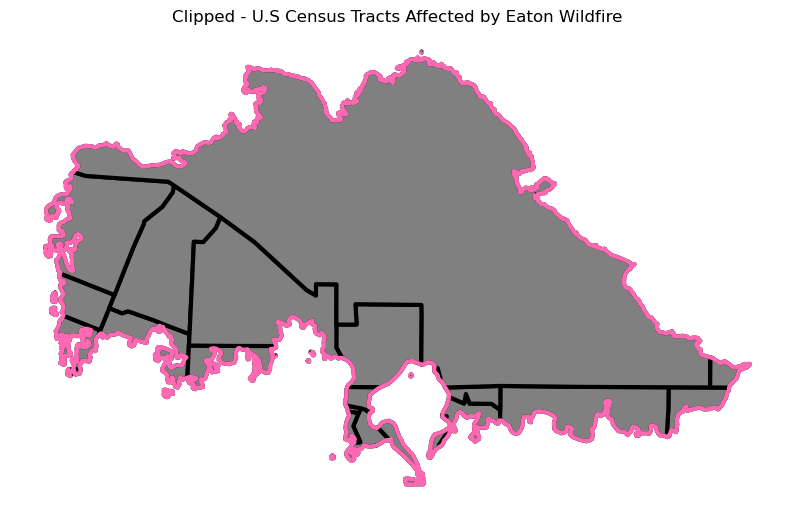

In [18]:
# Define figure and axis dimensions
fig, ax= plt.subplots(figsize = (10,10))

# Joined with EJI
eji_eaton_clip.plot(ax=ax, edgecolor= "black", facecolor= "grey", linewidth = 3)

# Eaton Reprojected
eaton.plot(ax=ax, edgecolor= "hotpink", color= "none", linewidth = 3)

# Set title
ax.set_title("Clipped - U.S Census Tracts Affected by Eaton Wildfire")

# Turn off axis ticks
ax.set_axis_off()


# Show plot
plt.show()

Now that we have the clipped EJI data within fire boundaries, we can analyze specific vulnerability metrics for affected communities. I am interested in the percentile of **housing units occupied by renters**, as renters often face unique challenges.

# Community’s Response To A Wildfire
### Renter Occupancy Across Fire Perimeters
#### Eaton and Palisades
Using the 2024 Environmental Justice Index data for California in the geodatabase data format, `EJI_2024_California`, I will plot the fire perimeters of Eaton and Palisades to showcase Housing Units, Occupied by Renters. In the Palisades area it is more common for more homeowners to own homes and rent them out since it is near a beach and often added to vacation rentals. The Eaton area is located in the foothills and canyons of the San Gabriel Mountains, near the cities of Altadena and Pasadena mountain ranges. 

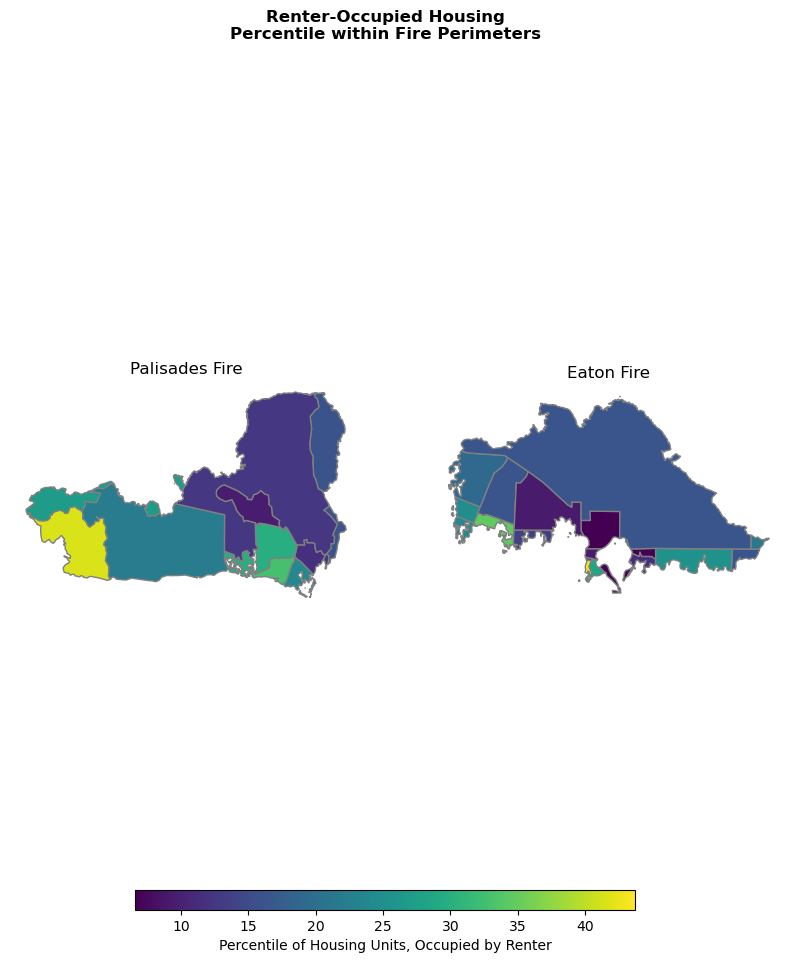

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))

# Add EJI Variable - Using Metadata
eji_variable = 'E_RENTER'

# Find common min/max for legend range
vmin = min(eji_palisades_clip[eji_variable].min(), eji_palisades_clip[eji_variable].min())
vmax = max(eji_eaton_clip[eji_variable].max(), eji_eaton_clip[eji_variable].max())

# Plot census tracts within Palisades perimeter
eji_palisades_clip.plot(
column= eji_variable,
vmin=vmin, vmax=vmax,
legend=False,
ax=ax1,
cmap='viridis',
edgecolor="grey")

ax1.set_title('Palisades Fire')
ax1.axis('off')

# Plot census tracts within Eaton perimeter
eji_eaton_clip.plot(
column=eji_variable,
vmin=vmin, vmax=vmax,
legend=False,
ax=ax2,
cmap='viridis',
edgecolor="grey")

ax2.set_title('Eaton Fire')
ax2.axis('off')

# Add overall title
fig.suptitle('Renter-Occupied Housing\nPercentile within Fire Perimeters',weight='bold')


# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap = 'viridis')
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Percentile of Housing Units, Occupied by Renter')
plt.show()

#### Interpretation
The spatial distribution of renter occupied housing reveals important differences between the two fire perimeter areas. In the Palisades fire perimeter, the western coastal tract shows the highest renter occupancy at approximately the 40th percentile, meaning this area has more renters than 40% of California census tracts likely reflecting the concentration of apartments and vacation rentals near the beach. The remaining Palisades tracts show lower percentile rankings (10-25th), indicating these inland areas are predominantly owner occupied. 

The Eaton fire perimeter displays greater variation, with some residential tracts reaching the 35-40th percentile range while large portions show minimal values corresponding to mountain terrain with little to no housing. These patterns indicate that both fires affected communities with notable renter populations, particularly in the Palisades coastal zone and Eaton's southwestern residential areas, suggesting these populations may face heightened vulnerability to displacement during the recovery process.

# References
- Assignment 4: Palisades & Eaton Fires. EDS 220 – Working with Environmental Datasets, 2025. https://meds-eds-220.github.io/EDS-eds-220-course/assignments/assignment4-palisades-eaton-fires.html. Accessed 17 Nov. 2025.
- Fritz, A., & Park, H. (2025, January 14). LA wildfires were larger and more intense due to planet-warming pollution, scientists report. CNN. https://www.cnn.com/2025/01/14/climate/los-angeles-fires-worse-global-warming/index.html
- Hoffman, R., Sarnoff, L., Kekatos, M., & Mansell, W. (2025, March 7). LA fires aftermath: How people are rebuilding after losing almost everything. ABC News. https://abcnews.go.com/US/la-wildfires-aftermath-insurance-housing-rebuild-update/story?id=119209482
- Microsoft Planetary Computer. Planetary Computer. (n.d.). https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2
- NPR. Satellite image ©2025 Maxar Technologies (January 9, 2025). https://www.kpbs.org/news/national/2025/01/09/photos-see-the-california-wildfires-destructive-force-in-satellite-images
- Palisades and Eaton dissolved fire perimeters (2025). County of Los Angeles Enterprise GIS. (2025, January 21). https://egis-lacounty.hub.arcgis.com/maps/ad51845ea5fb4eb483bc2a7c38b2370c/about
- Social dimensions of Eaton and Palisades fires. EDS 220 – Working with Environmental Datasets. https://meds-eds-220.github.io/MEDS-eds-220-course/discussion-sections/ds8-eji-eaton-palisades.html. Accessed 21 Nov. 2025.